In [3]:
import pandas as pd
import os
import sys

sys.path.insert(0, os.path.abspath(
    os.path.join(os.path.dirname('__file__'), '..')))
from src.encoding.tools import create_encoding_pipeline
from src.encoding.encoders import *

In [12]:
xls = pd.read_excel('hebdo_CHU_Dijon.xlsx', sheet_name="orientation", usecols="A:D")

In [5]:
print(xls)

      Annee  Semaine orientation  Valeur
0      2019        1        CHIR      47
1      2019        1         MED      43
2      2019        1         PSA      15
3      2019        1          SI      11
4      2019        1        UHCD     152
...     ...      ...         ...     ...
1796   2023       52         PSA      48
1797   2023       52          SI      34
1798   2023       52        UHCD     139
1799   2023       52      (vide)     858
1800   2023       52      autres      33

[1801 rows x 4 columns]


In [6]:
xls['orientation'].value_counts()

orientation
CHIR      264
UHCD      264
(vide)    264
MED       263
SI        251
autres    250
PSA       245
Name: count, dtype: int64

In [7]:
# Assuming your data is already in a DataFrame 'df'
df_pivot = xls.pivot(index=['Annee', 'Semaine'], columns='orientation', values='Valeur')


# Resetting the index to have a clean DataFrame
df_pivot = df_pivot.reset_index()
df_pivot.columns.name = None
# print(df_pivot.index)
# Display the new DataFrame
print(df_pivot)

     Annee  Semaine  (vide)  CHIR    MED   PSA    SI   UHCD  autres
0     2019        1   692.0  47.0   43.0  15.0  11.0  152.0    16.0
1     2019        2   879.0  78.0   63.0  66.0  21.0  213.0    28.0
2     2019        3  1135.0  47.0   57.0  36.0  15.0  218.0    32.0
3     2019        4  1041.0  51.0   65.0  58.0  18.0  205.0    20.0
4     2019        5  1125.0  57.0   54.0  57.0  20.0  211.0    17.0
..     ...      ...     ...   ...    ...   ...   ...    ...     ...
259   2023       48   806.0  57.0   71.0  92.0  21.0  181.0    40.0
260   2023       49   810.0  47.0   78.0  76.0  25.0  206.0    42.0
261   2023       50   829.0  58.0   90.0  87.0  17.0  177.0    45.0
262   2023       51   753.0  42.0  101.0  77.0  15.0  219.0    41.0
263   2023       52   858.0  46.0  109.0  48.0  34.0  139.0    33.0

[264 rows x 9 columns]


In [11]:
# Assuming your DataFrame is 'df'
# Create a new column 'Date' from 'Annee' and 'Semaine'
df_pivot['date'] = pd.to_datetime(df_pivot['Annee'].astype(str) + df_pivot['Semaine'].astype(str).str.zfill(2) + '7', format='%G%V%u')

# Drop the 'Annee' and 'Semaine' columns if you no longer need them
df = df_pivot.drop(columns=['Annee', 'Semaine'])

# Set the 'Date' column as the index
df = df.set_index('date')

# Display the updated DataFrame with 'Date' as the index
df = df.fillna(10)
print(df)


            (vide)  CHIR    MED   PSA    SI   UHCD  autres
date                                                      
2019-01-06   692.0  47.0   43.0  15.0  11.0  152.0    16.0
2019-01-13   879.0  78.0   63.0  66.0  21.0  213.0    28.0
2019-01-20  1135.0  47.0   57.0  36.0  15.0  218.0    32.0
2019-01-27  1041.0  51.0   65.0  58.0  18.0  205.0    20.0
2019-02-03  1125.0  57.0   54.0  57.0  20.0  211.0    17.0
...            ...   ...    ...   ...   ...    ...     ...
2023-12-03   806.0  57.0   71.0  92.0  21.0  181.0    40.0
2023-12-10   810.0  47.0   78.0  76.0  25.0  206.0    42.0
2023-12-17   829.0  58.0   90.0  87.0  17.0  177.0    45.0
2023-12-24   753.0  42.0  101.0  77.0  15.0  219.0    41.0
2023-12-31   858.0  46.0  109.0  48.0  34.0  139.0    33.0

[264 rows x 7 columns]


In [1]:
df

NameError: name 'df' is not defined

In [864]:
prefix = "nb_"
df.columns = [prefix + str(col) for col in df.columns]

print(df)

            nb_(vide)  nb_CHIR  nb_MED  nb_PSA  nb_SI  nb_UHCD  nb_autres
date                                                                     
2019-01-06      692.0     47.0    43.0    15.0   11.0    152.0       16.0
2019-01-13      879.0     78.0    63.0    66.0   21.0    213.0       28.0
2019-01-20     1135.0     47.0    57.0    36.0   15.0    218.0       32.0
2019-01-27     1041.0     51.0    65.0    58.0   18.0    205.0       20.0
2019-02-03     1125.0     57.0    54.0    57.0   20.0    211.0       17.0
...               ...      ...     ...     ...    ...      ...        ...
2023-12-03      806.0     57.0    71.0    92.0   21.0    181.0       40.0
2023-12-10      810.0     47.0    78.0    76.0   25.0    206.0       42.0
2023-12-17      829.0     58.0    90.0    87.0   17.0    177.0       45.0
2023-12-24      753.0     42.0   101.0    77.0   15.0    219.0       41.0
2023-12-31      858.0     46.0   109.0    48.0   34.0    139.0       33.0

[264 rows x 7 columns]


In [865]:
targets = ['nb_(vide)',	'nb_CHIR',	'nb_MED',	'nb_PSA',	'nb_SI',	'nb_UHCD',	'nb_autres']


In [866]:
missing_values = df[targets].isnull().sum()
missing_values

nb_(vide)     0
nb_CHIR       0
nb_MED        1
nb_PSA       19
nb_SI        13
nb_UHCD       0
nb_autres    14
dtype: int64

In [867]:
df_incomplet = pd.read_feather("../data/basetabulardataset/data_BaseTabularDataset_nb_vers_hospit.feather")
df_incomplet

,O3_FR26005,O3_FR26010,PM10_FR26005,PM10_FR26010,PM10_FR26014,PM10_FR26094,PM25_FR26005,PM25_FR26094,NO2_FR26005,NO2_FR26010,...,JO (F),Jeux Olympiques,Suruga Bank Champi.,The Atlantic Cup,Tournoi Toulon,UEFA Nations Leagu.,UEFA Nations League,LGF1,CL,nb_accidents
date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,36.0,37.0,12.0,15.0,12.0,19.0,6.6,6.8,16.0,6.9,...,0,0,0,0,0,0,0,0,0,0.0
2019-01-02,62.0,69.0,15.0,15.0,10.0,19.0,4.6,6.8,11.0,6.9,...,0,0,0,0,0,0,0,0,0,0.0
2019-01-03,51.0,63.0,20.0,15.0,16.0,19.0,7.7,6.8,15.0,6.9,...,0,0,0,0,0,0,0,0,0,0.0
2019-01-04,42.0,56.0,19.0,15.0,16.0,19.0,12.0,6.8,20.0,6.9,...,0,0,0,0,0,0,0,0,0,0.0
2019-01-05,40.0,44.0,17.0,15.0,15.0,19.0,11.0,6.8,14.0,6.9,...,0,0,0,0,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,22.0,29.0,21.0,15.0,19.0,18.0,17.0,8.0,20.0,6.9,...,0,0,0,0,0,0,0,0,0,0.0
2023-12-28,41.0,42.0,14.0,15.0,14.0,15.0,9.5,12.0,17.0,6.9,...,0,0,0,0,0,0,0,0,0,0.0
2023-12-29,48.0,49.0,12.0,15.0,12.0,11.0,8.0,7.6,10.0,6.9,...,0,0,0,0,0,0,0,0,0,0.0


In [868]:
df_incomplet.drop(columns='HNFC_moving', inplace=True)
cols = df_incomplet.select_dtypes(include='category').columns.to_list()

df_incomplet[cols] = df_incomplet[cols].astype('int64')

df_resample = df_incomplet.resample('W').sum()
df_resample


,O3_FR26005,O3_FR26010,PM10_FR26005,PM10_FR26010,PM10_FR26014,PM10_FR26094,PM25_FR26005,PM25_FR26094,NO2_FR26005,NO2_FR26010,...,JO (F),Jeux Olympiques,Suruga Bank Champi.,The Atlantic Cup,Tournoi Toulon,UEFA Nations Leagu.,UEFA Nations League,LGF1,CL,nb_accidents
date,,,,,,,,,,,,,,,,,,,,,
2019-01-06,279.0,321.0,97.0,90.0,79.0,114.0,51.0,40.80,86.0,41.4,...,0,0,0,0,0,0,0,0,0,1.0
2019-01-13,288.0,344.0,113.0,105.0,87.0,133.0,62.9,47.60,119.8,48.3,...,0,0,0,0,0,0,0,0,0,4.0
2019-01-20,221.0,277.0,157.0,105.0,132.0,133.0,96.3,47.60,185.0,48.3,...,0,0,0,0,0,0,0,0,0,8.0
2019-01-27,289.0,325.0,155.0,105.0,137.0,133.0,112.9,47.60,157.0,48.3,...,0,0,0,0,0,0,0,0,0,2.0
2019-02-03,339.0,367.0,86.0,105.0,56.0,133.0,41.6,47.60,128.0,48.3,...,0,0,0,0,0,0,0,0,0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-03,185.0,210.0,101.0,105.0,114.0,110.0,81.9,31.03,78.5,48.3,...,0,0,0,0,0,0,0,0,0,0.0
2023-12-10,233.0,266.0,88.0,105.0,79.0,87.0,56.1,23.49,110.1,48.3,...,0,0,0,0,0,0,0,0,0,0.0
2023-12-17,250.0,298.0,76.0,105.0,68.0,23.0,43.3,2.02,108.0,48.3,...,0,0,0,0,0,0,0,0,0,0.0


In [869]:
df_final = df_resample.join(df, on='date')
df_final

,O3_FR26005,O3_FR26010,PM10_FR26005,PM10_FR26010,PM10_FR26014,PM10_FR26094,PM25_FR26005,PM25_FR26094,NO2_FR26005,NO2_FR26010,...,LGF1,CL,nb_accidents,nb_(vide),nb_CHIR,nb_MED,nb_PSA,nb_SI,nb_UHCD,nb_autres
date,,,,,,,,,,,,,,,,,,,,,
2019-01-06,279.0,321.0,97.0,90.0,79.0,114.0,51.0,40.80,86.0,41.4,...,0,0,1.0,692.0,47.0,43.0,15.0,11.0,152.0,16.0
2019-01-13,288.0,344.0,113.0,105.0,87.0,133.0,62.9,47.60,119.8,48.3,...,0,0,4.0,879.0,78.0,63.0,66.0,21.0,213.0,28.0
2019-01-20,221.0,277.0,157.0,105.0,132.0,133.0,96.3,47.60,185.0,48.3,...,0,0,8.0,1135.0,47.0,57.0,36.0,15.0,218.0,32.0
2019-01-27,289.0,325.0,155.0,105.0,137.0,133.0,112.9,47.60,157.0,48.3,...,0,0,2.0,1041.0,51.0,65.0,58.0,18.0,205.0,20.0
2019-02-03,339.0,367.0,86.0,105.0,56.0,133.0,41.6,47.60,128.0,48.3,...,0,0,3.0,1125.0,57.0,54.0,57.0,20.0,211.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-03,185.0,210.0,101.0,105.0,114.0,110.0,81.9,31.03,78.5,48.3,...,0,0,0.0,806.0,57.0,71.0,92.0,21.0,181.0,40.0
2023-12-10,233.0,266.0,88.0,105.0,79.0,87.0,56.1,23.49,110.1,48.3,...,0,0,0.0,810.0,47.0,78.0,76.0,25.0,206.0,42.0
2023-12-17,250.0,298.0,76.0,105.0,68.0,23.0,43.3,2.02,108.0,48.3,...,0,0,0.0,829.0,58.0,90.0,87.0,17.0,177.0,45.0


In [870]:

df_final[targets] = df_final[targets].fillna(10)

In [871]:
# count the number of missing values in each column
missing_values = df_final[targets].isnull().sum()
missing_values

nb_(vide)    0
nb_CHIR      0
nb_MED       0
nb_PSA       0
nb_SI        0
nb_UHCD      0
nb_autres    0
dtype: int64

In [872]:
df_final.drop('nb_vers_hospit', axis=1, inplace=True)

In [873]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split


# read data
data = df_final.copy(deep=True)

# split data into train and test sets
train_set, test_set = train_test_split(data, test_size=0.2, shuffle=False)
train_set, val_set = train_test_split(train_set, test_size=0.2, shuffle=False)

targets = ['nb_(vide)',	'nb_CHIR',	'nb_MED',	'nb_PSA',	'nb_SI',	'nb_UHCD',	'nb_autres']

target = 0

x_train = train_set.drop(targets, axis=1)
y_train = train_set[targets[target]]

x_test = test_set.drop(targets, axis=1)
y_test = test_set[targets[target]]

x_val = val_set.drop(targets, axis=1)
y_val = val_set[targets[target]]

# # create model instance

# #bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')
# #bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='multi:softprob')
# # fit model
# bst.fit(X_train, y_train)
# # make predictions
# preds = bst.predict(X_test)

# print(preds == y_test)

<Axes: xlabel='date'>

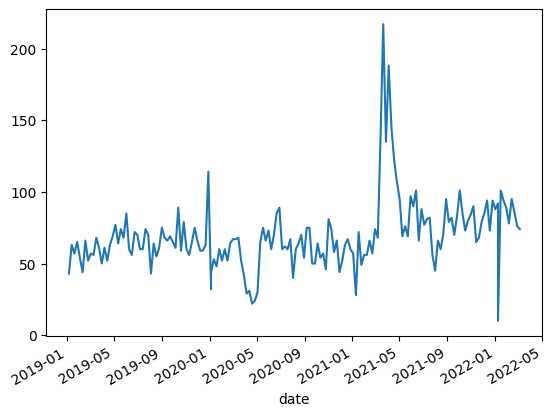

In [874]:
train_set[targets[2]].plot()

In [875]:
encoders_dict = {
    'number': {
        'as_number': {
            'imputers': [imputers.SimpleImputer(strategy='mean')],
            'encoders': [
                ne.StandardScaler(),

            ]
        }
    },
    'category': {
        'as_category': {
            'imputers': [imputers.SimpleImputer(strategy='most_frequent')],
            'encoders': [
                # ne.TargetEncoder(target_type='continuous-multioutput'),
                # ne.TargetEncoder(target_type='continuous'),
                ne.MultiTargetEncoder(drop_invariant=True, return_df=True),
            ]
        }
    },
    'datetime': {
        'as_number': {
            'imputers': [de.DateFeatureExtractor()],
            'encoders': [
                ne.CyclicalFeatures(drop_original=True)
            ]
        },
        'as_category': {
            'imputers': [de.DateFeatureExtractor(dtype='category')],
            'encoders': [
                # ne.TargetEncoder(target_type='continuous'),
                ne.MultiTargetEncoder(drop_invariant=True, return_df=True),


            ]
        }
    }
}

In [876]:
processor = create_encoding_pipeline(encoders_dict)
processor.fit(x_train, y_train)

Creating encoding pipeline
[FeatureUnion]  (step 1 of 4) Processing columntransformer-1, total=   0.0s
[FeatureUnion]  (step 2 of 4) Processing columntransformer-2, total=   0.0s
[FeatureUnion]  (step 3 of 4) Processing columntransformer-3, total=   0.0s
[FeatureUnion]  (step 4 of 4) Processing columntransformer-4, total=   0.0s


FeatureUnion(transformer_list=[('columntransformer-1',
                                ColumnTransformer(transformers=[('pipeline',
                                                                 Pipeline(steps=[('featureunion-1',
                                                                                  FeatureUnion(transformer_list=[('simpleimputer',
                                                                                                                  SimpleImputer())])),
                                                                                 ('featureunion-2',
                                                                                  FeatureUnion(transformer_list=[('standardscaler',
                                                                                                                  StandardScaler())]))]),
                                                                 <sklearn.compose._column_transformer.make_column_selector obj...
                                ColumnTransformer(transformers=[('pipeline',
                                                                 Pipeline(steps=[('featureunion-1',
                                                                                  FeatureUnion(transformer_list=[('datefeatureextractor',
                                                                                                                  DateFeatureExtractor(dtype='category'))])),
                                                                                 ('featureunion-2',
                                                                                  FeatureUnion(transformer_list=[('multitargetencoder',
                                                                                                                  MultiTargetEncoder(drop_invariant=True))]))]),
                                                                 <sklearn.compose._column_transformer.make_column_selector object at 0x13f90ada0>)]))],
             verbose=True)

In [877]:
encoded_x_train = processor.transform(x_train)
encoded_x_train.columns = [col.split('__')[-1] for col in encoded_x_train.columns]
print(encoded_x_train)

            O3_FR26005  O3_FR26010  PM10_FR26005  PM10_FR26010  PM10_FR26014  \
date                                                                           
2019-01-06   -0.736509   -0.711692     -0.432497    -12.922848     -0.410473   
2019-01-13   -0.673817   -0.549470      0.024931      0.077382     -0.191771   
2019-01-20   -1.140525   -1.022028      1.282858      0.077382      1.038428   
2019-01-27   -0.666851   -0.683479      1.225679      0.077382      1.175117   
2019-02-03   -0.318561   -0.387249     -0.746979      0.077382     -1.039242   
...                ...         ...           ...           ...           ...   
2022-02-06   -0.513603   -0.316718     -1.090050      0.077382     -0.547162   
2022-02-13   -0.687748   -0.549470      1.282858      0.077382      1.448495   
2022-02-20    0.134216   -0.041647     -0.832747      0.077382     -0.711189   
2022-02-27    0.043661    0.113521     -0.032248      0.077382      0.136282   
2022-03-06   -0.144416    0.134681      

In [878]:
encoded_x_test = processor.transform(x_test)
encoded_x_test.columns = [col.split('__')[-1] for col in encoded_x_test.columns]
print(encoded_x_test)

            O3_FR26005  O3_FR26010  PM10_FR26005  PM10_FR26010  PM10_FR26014  \
date                                                                           
2023-01-08   -0.827064   -0.895072     -0.689801      0.077382     -0.683851   
2023-01-08   -0.827064   -0.895072     -0.689801      0.077382     -0.683851   
2023-01-15    0.071524   -0.133337     -0.975693      0.077382     -0.711189   
2023-01-22   -0.778304   -0.620001     -0.546855      0.077382     -0.519824   
2023-01-29   -0.945483   -0.866860     -0.775569      0.077382     -0.355798   
2023-02-05   -0.430014   -0.232081     -0.318140      0.077382     -0.219109   
2023-02-12   -0.785270   -0.394302      2.140535      0.077382      2.459992   
2023-02-19   -0.680783   -0.330824      2.626552      0.077382      2.870059   
2023-02-26   -0.854928   -0.754010      1.197090      0.077382      1.202455   
2023-03-05   -0.165313    0.191105      2.226303      0.077382      2.213952   
2023-03-12    0.357122    0.501442     -

In [879]:
encoded_x_val = processor.transform(x_val)
encoded_x_val.columns = [col.split('__')[-1] for col in encoded_x_val.columns]
print(encoded_x_val)

            O3_FR26005  O3_FR26010  PM10_FR26005  PM10_FR26010  PM10_FR26014  \
date                                                                           
2022-03-13    0.252635    0.289849      1.883232      0.077382      1.940575   
2022-03-20   -0.186211   -0.147443      1.654518      0.077382      1.694535   
2022-03-27    1.165154    1.587620      3.198337      0.077382      2.596681   
2022-04-03    0.447677    0.452070      1.826053      0.077382      1.503170   
2022-04-10    0.329258    0.268690     -1.032872      0.077382     -1.339957   
2022-04-17    0.970112    1.093903      0.196466      0.077382     -0.273784   
2022-04-24    1.116394    1.122115     -0.260962      0.077382     -0.683851   
2022-05-01    0.865625    0.854097      0.225055      0.077382     -0.888884   
2022-05-08    1.186052    1.242018      0.368002      0.077382     -1.162262   
2022-05-15    0.865625    0.755354      0.482359      0.077382     -0.137096   
2022-05-22    0.907420    0.790619      

In [880]:
import xgboost as xgb
import src.models.sklearn_models_config as config

params = {
    'verbosity':2,
    'n_estimators' : 200
}

early_stop = False
if early_stop:
    params['early_stopping_rounds'] = 10
    params['eval_set'] = [(encoded_x_val, y_val)]
    fit_params={"eval_set":[(encoded_x_val, y_val)]}
else:
    fit_params = {}

config_model_class = False
if config_model_class:
    model = config.get_model('xgboost', targets[target], 'cpu', 'regression', 'rmse', 'rmse', params)
    model.fit(encoded_x_train, y_train, "skip", grid_params={'max_depth': [3, 5, 7, 9], 'learning_rate': [0.1, 0.01, 0.001]}, fit_params=fit_params)
else:
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, max_depth=5, learning_rate=0.1, n_jobs=-1)
    model.fit(encoded_x_train, y_train)




In [881]:

y_pred = model.predict(encoded_x_test)
y_pred

array([958.3796 , 958.3796 , 763.0428 , 721.2047 , 668.2122 , 682.185  ,
       532.79266, 726.88196, 861.58936, 732.1965 , 854.87836, 956.13   ,
       796.1347 , 925.91565, 856.78503, 766.50226, 782.0893 , 943.36554,
       953.3792 , 885.26105, 919.92694, 920.45795, 961.36847, 938.00903,
       926.28107, 978.6536 , 947.26996, 799.2616 , 886.212  , 583.10364,
       836.1952 , 652.0099 , 608.5437 , 814.7872 , 800.70526, 818.31323,
       742.8175 , 901.7141 , 883.1041 , 930.51355, 914.9371 , 916.35547,
       954.07184, 792.7014 , 801.1981 , 779.53827, 897.35095, 808.9091 ,
       858.7617 , 881.641  , 858.96814, 895.1973 , 884.3658 ],
      dtype=float32)

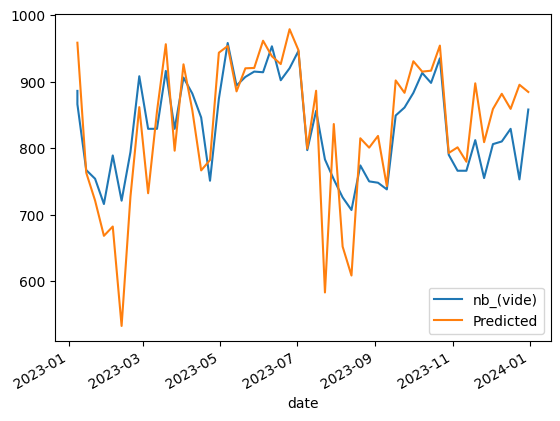

In [882]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

y_test.plot(ax=ax, label=targets[target])

pd.Series(y_pred, index=y_test.index).plot(ax=ax, label='Predicted')

plt.legend()

plt.show()